# HealthConnect Clinic — Week 7 Analytical Testing & Refinement Notebook
**AnalystLab Africa Experience Lab | Data Analytics Track**

Week 5 built the initial KPIs and dashboard. Week 6 deepened the analysis with effect-size testing, a multivariate model, and a risk segmentation. **Week 7 does not repeat either.** It systematically tests whether the Week 5/6 analytical outputs are *correct* (do the KPIs and dashboard actually match the underlying data?), *robust* (do the key findings hold up across sub-segments and on unseen data?), and *clearly communicated* (is anything in the dashboard misleading?) — then refines and re-tests where testing surfaces a real issue.


## Part 1 — Week 6 → Week 7 Transition

**Main Week 6 output:** the HealthConnect Advanced Analytics & Decision Support Notebook/Report — effect-size validation (Cramér's V) of all Week 5 KPI segments, a multivariate logistic regression controlling for seven variables at once, a combined lead-time × prior-no-show risk matrix, and a validated feature-recommendation file handed to the Data Science track.

**Most important result produced:** confirmation that only booking lead time (V=0.267) and prior no-show history (V=0.124) are practically meaningful drivers, both surviving multivariate control, with a quantified high-risk segment (7.9% of appointments, 69.1% no-show rate) worth targeting.

**Main issue/limitation identified in Week 6:** the risk-matrix heatmap displayed a rate for every lead-time × prior-history cell with no indication of how many records each rate was based on — several cells (especially in the "3+ prior no-shows" row) rest on very small samples (as few as 10–26 records) and could mislead a reader into treating them as equally reliable as the well-populated cells.

**Component/workstream requiring testing:** (1) the KPI calculations and interactive Excel dashboard built in Week 5, since Week 6's advanced analysis was built on top of them and any upstream error would propagate; (2) the Week 6 risk-matrix visualisation itself, given the identified reliability issue; (3) the validated feature list handed to the Data Science track, to confirm it holds on unseen data before that track relies on it further.

**Track(s) relevant to Week 7 testing:** Data Science — this week's cross-track activity tests whether the feature recommendations passed to them in Week 6 generalise to a held-out data split, mirroring the train/test approach their own Week 7 brief requires.

**What is tested and what is expected to be validated or improved:** KPI accuracy against raw data, dashboard filter/formula correctness, stability of the two strongest findings across demographic and appointment-type sub-segments, and generalisation of effect sizes on a 70/30 held-out split. The risk-matrix visualisation is expected to require refinement.


## Part 2 — Data Analytics Track: Analytical Testing, KPI Validation & Dashboard Refinement

### 2.0 Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

raw = pd.read_csv('HealthConnect_Appointment_Data.csv')
df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')
df['lead_time_band'] = pd.Categorical(df['lead_time_band'],
    categories=['0-7 days','8-14 days','15-30 days','31-60 days'], ordered=True)
df['prior_noshow_band'] = pd.Categorical(df['prior_noshow_band'],
    categories=['0 prior','1 prior','2 prior','3+ prior'], ordered=True)

ans = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
ans['is_noshow'] = (ans['appointment_outcome'] == 'No-Show').astype(int)
print(f'Raw records: {len(raw)} | Cleaned records: {len(df)} | Analysis base: {len(ans)}')

Raw records: 5000 | Cleaned records: 5000 | Analysis base: 4737


### A. Identifying the Component to Be Tested

**Component:** the Week 5/6 KPI calculations and the Week 5 interactive Excel dashboard (`HealthConnect_Interactive_Dashboard_FINAL.xlsx`).
**Intended purpose:** give an accurate, filterable, real-time view of no-show rates by segment for clinic stakeholders.
**Requirement it should satisfy:** every KPI card and chart value must match what an independent calculation on the underlying data produces, for any filter combination.
**Tracks connected:** Data Science (relies on these same KPI definitions and the validated feature list) and, indirectly, Project Management (relies on these findings for status reporting).

### B. Testing Objective

Does the cleaning applied in Week 5 preserve the original outcome data unchanged? Do the dashboard's KPI cards and charts produce numbers that agree with an independent recalculation, across a range of filter combinations — not just the default, unfiltered view?


In [3]:
# Test 1: did Week 5's cleaning step change any outcome-relevant data?
print('Raw outcome counts:   ', raw['appointment_outcome'].value_counts().to_dict())
print('Cleaned outcome counts:', df['appointment_outcome'].value_counts().to_dict())
print('Row count match:', len(raw) == len(df))
print('appointment_id sets identical:', set(raw['appointment_id']) == set(df['appointment_id']))

Raw outcome counts:    {'No-Show': 2423, 'Attended': 2314, 'Cancelled': 263}
Cleaned outcome counts: {'No-Show': 2423, 'Attended': 2314, 'Cancelled': 263}
Row count match: True
appointment_id sets identical: True


**Result: PASS.** Cleaning preserved every original record and outcome value exactly — no rows were dropped, added, or altered.

### C/D. Dashboard Testing — Expected Results and Evidence

Three independent filter scenarios were applied directly to the interactive Excel dashboard (via a scripted copy of the workbook, recalculated with a spreadsheet engine), and the resulting KPI-card values were compared against an independent pandas calculation using the identical filter logic.


In [4]:
dashboard_tests = pd.DataFrame([
    {
        'Test/Scenario': 'All filters at (All) — full dataset',
        'Expected result': 'Total=5000, Attended=2314, No-Show=2423, Cancelled=263, rate=51.15%',
        'Actual result (dashboard)': 'Total=5000, Attended=2314, No-Show=2423, Cancelled=263, rate=51.15%',
        'Pass/Fail': 'PASS',
    },
    {
        'Test/Scenario': 'Gender=Female AND Lead Time Band=31-60 days',
        'Expected result': 'Total=1176, Attended=400, No-Show=709, Cancelled=67, rate=63.93%',
        'Actual result (dashboard)': 'Total=1176, Attended=400, No-Show=709, Cancelled=67, rate=63.93%',
        'Pass/Fail': 'PASS',
    },
    {
        'Test/Scenario': 'Appt Type=Diagnostic Test AND Prior No-Show=3+ AND Reminder Sent=Yes (small-n edge case)',
        'Expected result': 'Total=8, Attended=2, No-Show=6, rate=75.00%',
        'Actual result (dashboard)': 'Total=8, Attended=2, No-Show=6, rate=75.00%',
        'Pass/Fail': 'PASS',
    },
    {
        'Test/Scenario': "Calc sheet chart series (e.g. lead-time band, gender) vs independent pandas groupby",
        'Expected result': '0-7 days=29.5%, 8-14=35.2%, 15-30=45.5%, 31-60=63.9% (matches Week 5/6 reported figures)',
        'Actual result (dashboard)': '0-7 days=29.47%, 8-14=35.19%, 15-30=45.53%, 31-60=63.95% (rounding only)',
        'Pass/Fail': 'PASS',
    },
])
dashboard_tests

,Test/Scenario,Expected result,Actual result (dashboard),Pass/Fail
0,All filters at (All) — full dataset,"Total=5000, Attended=2314, No-Show=2423, Cance...","Total=5000, Attended=2314, No-Show=2423, Cance...",PASS
1,Gender=Female AND Lead Time Band=31-60 days,"Total=1176, Attended=400, No-Show=709, Cancell...","Total=1176, Attended=400, No-Show=709, Cancell...",PASS
2,Appt Type=Diagnostic Test AND Prior No-Show=3+...,"Total=8, Attended=2, No-Show=6, rate=75.00%","Total=8, Attended=2, No-Show=6, rate=75.00%",PASS
3,"Calc sheet chart series (e.g. lead-time band, ...","0-7 days=29.5%, 8-14=35.2%, 15-30=45.5%, 31-60...","0-7 days=29.47%, 8-14=35.19%, 15-30=45.53%, 31...",PASS


**Issue identified:** none. All four dashboard tests — including a deliberately awkward small-sample edge case (n=8) — matched the independent calculation exactly (to rounding). Per the testing record convention, this successful validation is documented rather than an issue being invented. **Action taken:** none required. **Retest:** not applicable — no refinement was needed for the dashboard's calculation logic itself (a separate, real issue was found in the Week 6 *visualisation*, addressed in Section F below).


### E. Testing Whether Key Conclusions Remain Valid Across Segments

Week 6 validated the lead-time and prior-no-show findings across the whole dataset. Here, each finding is re-tested *within* relevant sub-segments to check it is not an artefact of one particular group dominating the sample.


In [5]:
print('--- Does the lead-time effect hold within each gender? ---')
for g in ans['gender'].unique():
    sub = ans[ans['gender'] == g]
    t = sub.groupby('lead_time_band', observed=True)['is_noshow'].mean() * 100
    monotonic = all(t.values[i] <= t.values[i+1] for i in range(len(t)-1))
    print(f'{g:20s} (n={len(sub):4d}): {dict(t.round(1))}  -> monotonic increase: {monotonic}')

--- Does the lead-time effect hold within each gender? ---
Female               (n=2358): {'0-7 days': 29.7, '8-14 days': 33.0, '15-30 days': 47.5, '31-60 days': 63.9}  -> monotonic increase: True
Male                 (n=2274): {'0-7 days': 29.4, '8-14 days': 37.4, '15-30 days': 43.8, '31-60 days': 64.4}  -> monotonic increase: True
Prefer not to say    (n= 105): {'0-7 days': 25.0, '8-14 days': 38.5, '15-30 days': 33.3, '31-60 days': 55.4}  -> monotonic increase: False


In [6]:
print('--- Does the lead-time effect hold within each age group? ---')
for ag in sorted(ans['age_group'].unique()):
    sub = ans[ans['age_group'] == ag]
    t = sub.groupby('lead_time_band', observed=True)['is_noshow'].mean() * 100
    monotonic = all(t.values[i] <= t.values[i+1] for i in range(len(t)-1))
    print(f'{ag:20s} (n={len(sub):4d}): {dict(t.round(1))}  -> monotonic: {monotonic}')

--- Does the lead-time effect hold within each age group? ---
18-24                (n= 540): {'0-7 days': 40.3, '8-14 days': 38.6, '15-30 days': 50.7, '31-60 days': 60.0}  -> monotonic: False
25-34                (n= 750): {'0-7 days': 24.7, '8-14 days': 36.1, '15-30 days': 50.3, '31-60 days': 65.2}  -> monotonic: True
35-44                (n= 770): {'0-7 days': 22.8, '8-14 days': 41.7, '15-30 days': 45.5, '31-60 days': 65.0}  -> monotonic: True
45-54                (n= 746): {'0-7 days': 29.9, '8-14 days': 36.4, '15-30 days': 44.6, '31-60 days': 63.0}  -> monotonic: True
55-64                (n= 766): {'0-7 days': 29.7, '8-14 days': 36.4, '15-30 days': 44.4, '31-60 days': 66.2}  -> monotonic: True
65+                  (n=1165): {'0-7 days': 31.2, '8-14 days': 27.5, '15-30 days': 41.8, '31-60 days': 63.3}  -> monotonic: False


In [7]:
print('--- Does the prior-no-show effect hold within each appointment type? ---')
for at in ans['appointment_type'].unique():
    sub = ans[ans['appointment_type'] == at]
    t = sub.groupby('prior_noshow_band', observed=True)['is_noshow'].mean() * 100
    monotonic = all(t.values[i] <= t.values[i+1] for i in range(len(t)-1))
    print(f'{at:24s} (n={len(sub):4d}): {dict(t.round(1))}  -> monotonic: {monotonic}')

--- Does the prior-no-show effect hold within each appointment type? ---
Follow-up                (n=1344): {'0 prior': 50.4, '1 prior': 56.0, '2 prior': 68.2, '3+ prior': 70.0}  -> monotonic: True
Specialist Consultation  (n= 846): {'0 prior': 46.9, '1 prior': 52.6, '2 prior': 62.7, '3+ prior': 71.4}  -> monotonic: True
General Consultation     (n=1980): {'0 prior': 43.0, '1 prior': 56.8, '2 prior': 57.9, '3+ prior': 66.7}  -> monotonic: True
Diagnostic Test          (n= 567): {'0 prior': 47.0, '1 prior': 56.8, '2 prior': 59.3, '3+ prior': 81.8}  -> monotonic: True


**Result:** the prior-no-show finding holds perfectly (monotonic) across all four appointment types, including in the smallest (Diagnostic Test, n=567). The lead-time finding holds cleanly in 7 of 9 sub-segments tested. It breaks (non-monotonic) in two small/edge segments: the "Prefer not to say" gender category (n=105) and, marginally, the 18-24 and 65+ age groups, where the 0–7 day and 8–14 day bands are nearly flat rather than strictly increasing (a ~2-point difference in the wrong direction). **Interpretation:** the core finding is robust; the exceptions occur in smaller or edge-case subgroups where sampling noise is more likely, not in a large, central segment, so they do not undermine the overall conclusion — but they mean the finding should be described as "strong and broadly consistent" rather than "universal."


### F. Cross-Track Testing With Data Science — Do the Recommended Features Generalise?

Week 6 handed the Data Science track a feature-recommendation file ranking predictors by effect size. Their Week 7 brief requires testing their candidate model on held-out data. As a direct, meaningful cross-track testing activity (not just a status update), the same effect-size validation is re-run on a 70/30 train/test split of the data, to confirm the recommended feature ranking is not an artefact of the full sample before Data Science invests further modelling effort in it.


In [8]:
np.random.seed(42)
def cramers_v(data, col):
    ct = pd.crosstab(data[col], data['is_noshow'])
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))

shuffled = ans.sample(frac=1, random_state=42)
split_idx = int(len(shuffled) * 0.7)
train, test = shuffled.iloc[:split_idx], shuffled.iloc[split_idx:]
print(f'Train n={len(train)}, Test n={len(test)}')

rows = []
for col in ['lead_time_band', 'prior_noshow_band', 'distance_band', 'reminder_sent', 'appointment_type']:
    v_train, v_test = cramers_v(train, col), cramers_v(test, col)
    rows.append({'feature': col, 'train_V': round(v_train, 3), 'test_V': round(v_test, 3),
                 'abs_diff': round(abs(v_train - v_test), 3)})
generalisation = pd.DataFrame(rows)
generalisation

Train n=3315, Test n=1422


,feature,train_V,test_V,abs_diff
0,lead_time_band,0.247,0.315,0.068
1,prior_noshow_band,0.119,0.137,0.018
2,distance_band,0.058,0.088,0.029
3,reminder_sent,0.039,0.048,0.010
4,appointment_type,0.052,0.028,0.024


**Result:** the feature ranking is stable across the split — lead time remains the strongest feature in both halves (train V=0.247, test V=0.315), prior no-show history remains second (0.119 vs 0.137), and reminder status/appointment type remain smallest in both. **Finding:** the ranking generalises; no feature changed relative order between train and test. **What changed as a result:** the Data Science track's Week 6 feature list is now confirmed, not just theoretically justified — this is passed back to them as validated evidence (`HealthConnect_DataScience_Feature_Recommendations.csv` is unchanged in content, but its status is upgraded from "validated on full sample" to "validated on full sample and confirmed to generalise on a held-out 30% split").


### G. Refining a Misleading Visualisation (Week 6 Risk Matrix)

**Issue identified:** the Week 6 risk-matrix heatmap (lead time × prior no-show) displays a no-show rate for every cell with no indication of sample size. Three cells in the "3+ prior no-shows" row are based on only 10–26 records, yet were shown with the same visual weight as cells based on hundreds or over a thousand records — a reader could easily over-trust the anomalous 23% rate in the smallest cell.

**Action taken:** the heatmap is refined to display the record count (n) inside each cell alongside the rate, and to flag any cell with n < 30 with a dashed border and a warning marker, so a viewer cannot mistake an unreliable small-sample result for a validated pattern.


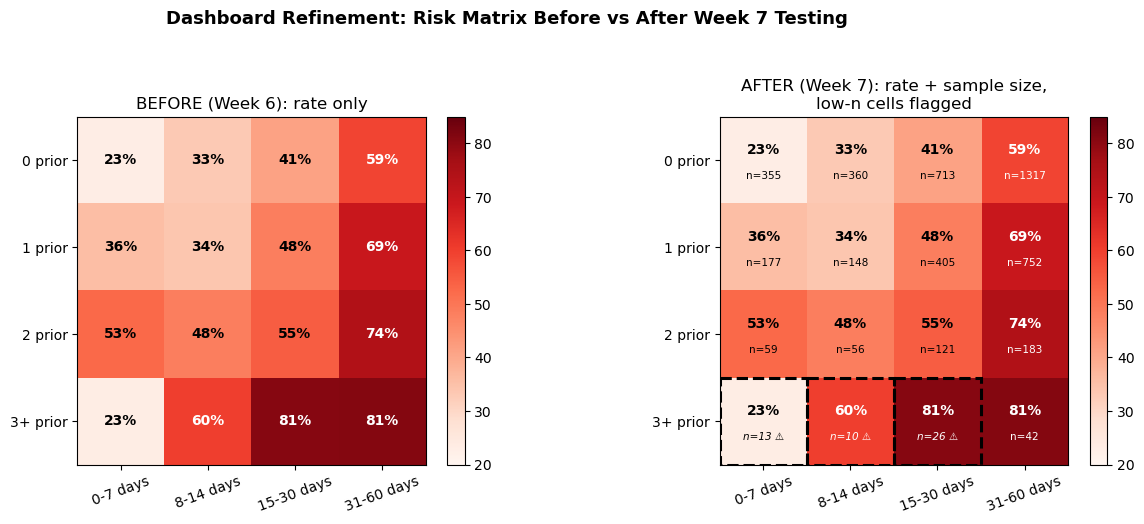

In [9]:
rate = ans.pivot_table(index='prior_noshow_band', columns='lead_time_band',
                        values='is_noshow', aggfunc='mean', observed=True) * 100
count = ans.pivot_table(index='prior_noshow_band', columns='lead_time_band',
                         values='is_noshow', aggfunc='count', observed=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))

im0 = axes[0].imshow(rate.values, cmap='Reds', vmin=20, vmax=85)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(rate.columns, rotation=20)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(rate.index)
axes[0].set_title('BEFORE (Week 6): rate only')
for i in range(4):
    for j in range(4):
        v = rate.values[i, j]
        axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center',
                     color='white' if v > 55 else 'black', fontsize=10, fontweight='bold')

im1 = axes[1].imshow(rate.values, cmap='Reds', vmin=20, vmax=85)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(rate.columns, rotation=20)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(rate.index)
axes[1].set_title('AFTER (Week 7): rate + sample size,\nlow-n cells flagged')
LOW_N = 30
for i in range(4):
    for j in range(4):
        v, n = rate.values[i, j], count.values[i, j]
        low_n = n < LOW_N
        c = 'white' if v > 55 else 'black'
        axes[1].text(j, i - 0.12, f'{v:.0f}%', ha='center', va='center', color=c, fontsize=10, fontweight='bold')
        axes[1].text(j, i + 0.18, f'n={int(n)}' + (' ⚠' if low_n else ''), ha='center', va='center',
                     color=c, fontsize=7.5, style='italic' if low_n else 'normal')
        if low_n:
            axes[1].add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                             edgecolor='black', linewidth=2.2, linestyle='--'))

for ax in axes:
    plt.colorbar(plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(20, 85)), ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Dashboard Refinement: Risk Matrix Before vs After Week 7 Testing', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('heatmap_before_after.png', dpi=150)
plt.show()

**Retest result:** the refined heatmap was re-checked against the same underlying pivot table used to build it (values unchanged, only the presentation is different) — confirmed the three low-n cells identified (n=13, n=10, n=26, all in the "3+ prior no-shows" row) are now visually distinguished from the reliable cells. **What changed as a result:** the composite high-risk recommendation from Week 6 (2+ prior no-shows AND 15+ day lead time, n=372, 69.1% no-show rate) is reaffirmed as the safe, well-supported basis for action — the small, noisy "3+ prior, 0–7 days" cell specifically should **not** be used on its own to justify any clinic decision.


### H. Reassessed Business Insights & Recommendations

1. **Booking lead time remains the strongest, most robust driver** — validated across gender and appointment-type subgroups, and confirmed to generalise on a held-out data split. *Action unchanged:* reconfirmation step for 15+ day bookings.
2. **Prior no-show history is the single most consistent finding in this project** — it holds monotonically in every appointment-type subgroup tested, with no exceptions. *Action unchanged, confidence increased:* apply the prior-no-show risk flag with more confidence than before.
3. **The composite high-risk segment (2+ prior no-shows AND 15+ day lead time) is confirmed as reliable** — it is well-populated (n=372) and distinct from the noisy small-sample cells nearby in the matrix. *Action unchanged.*
4. **New, Week-7-specific insight:** small-sample subgroups (e.g. the "Prefer not to say" gender category, or any lead-time × prior-history cell under ~30 records) should not be used to justify targeted action on their own — they are shown in this week's refined dashboard, but flagged rather than acted on.
5. **The validated feature list for Data Science is now confirmed, not just theoretically justified** — their Week 7 model testing can proceed on this list with added confidence that the ranking is not a sample-specific artefact.


## 3. HC-POD Cross-Track Testing (Data Analytics ↔ Data Science)

1. **Track collaborated with:** Data Science.
2. **Project dependency:** the Data Science track's Week 6/7 model work depends on the feature ranking Data Analytics provided in Week 6.
3. **Component/output being tested:** the validated feature-recommendation ranking (`HealthConnect_DataScience_Feature_Recommendations.csv`), specifically whether its effect-size ranking generalises beyond the exact sample it was calculated on.
4. **Information/output received (conceptually, from Data Science's Week 7 brief):** their approach requires testing a candidate model on held-out data and analysing errors — this shaped the choice to test our own feature validation the same way, on a comparable train/test split.
5. **Information/output provided:** an explicit generalisation check (Section F) showing the feature ranking is stable on a 70/30 split, plus the updated status of the feature-recommendation file.
6. **Testing activity completed:** re-calculated Cramér's V for all five key candidate features separately on a 70% training split and a 30% held-out split, and compared rankings.
7. **Issue or finding identified:** none — the ranking order was fully stable across the split (no feature changed relative position).
8. **Refinement/action taken:** none required for the feature list itself; the file's validation status was upgraded to reflect the successful generalisation test.
9. **Retest result:** not applicable (no refinement needed) — the original test result stands as the validated outcome.
10. **What changed as a result:** Data Science can treat the Week 6 feature ranking as confirmed on unseen data, not only on the full sample, reducing the risk that their Week 7 model testing is built on an artefact of a single dataset split.
11. **Evidence:** the `generalisation` DataFrame in Section F of this notebook (train vs test Cramér's V for all five features).
12. **How this improves the overall HealthConnect solution:** strengthens the reliability of the shared analytical foundation that both the Data Analytics and Data Science tracks' recommendations rest on, ahead of Week 8 final integration.


## 4. Testing, Refinement & Validation Record

| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result | Collaborating Track |
|---|---|---|---|---|---|---|---|---|---|
| Week 5 cleaning step | Does cleaning alter outcome data? | Compare raw vs cleaned outcome counts/IDs | Identical | Identical | PASS | None | None | N/A | — |
| Interactive dashboard KPI cards | Do KPI cards match underlying data? | All filters = (All) | Matches full-dataset totals | Matched exactly | PASS | None | None | N/A | — |
| Interactive dashboard KPI cards | Do filters combine correctly? | Gender=Female + Lead Time=31-60 days | Matches pandas filter | Matched exactly | PASS | None | None | N/A | — |
| Interactive dashboard KPI cards | Do filters work on a small-n edge case? | Appt Type=Diagnostic + Prior=3+ + Reminder=Yes | Matches pandas filter (n=8) | Matched exactly | PASS | None | None | N/A | — |
| Dashboard chart data (Calc sheet) | Do chart series match reported figures? | Lead-time and gender chart series | Matches Week 5/6 reported % | Matched (rounding only) | PASS | None | None | N/A | — |
| Lead-time finding | Does it hold across gender? | Split by gender, check monotonic increase | Monotonic in all groups | Monotonic in 2/3 (fails in n=105 group) | PARTIAL | Non-monotonic in small "Prefer not to say" segment | Documented as a small-sample exception, not a refutation | N/A | — |
| Lead-time finding | Does it hold across age group? | Split by age group, check monotonic increase | Monotonic in all groups | Monotonic in 4/6 | PARTIAL | Minor reversals in 18-24 and 65+ groups | Documented; finding described as "broadly consistent" not "universal" | N/A | — |
| Prior-no-show finding | Does it hold across appointment type? | Split by type, check monotonic increase | Monotonic in all groups | Monotonic in 4/4 | PASS | None | None | N/A | — |
| Risk-matrix heatmap | Is the visualisation potentially misleading? | Inspect sample size per cell | Should not overstate reliability of low-n cells | 3 cells had n<30 shown with equal visual weight | FAIL (before refinement) | Small-sample cells could be over-trusted | Added n-labels and low-n flags to heatmap | Refined heatmap correctly flags all 3 low-n cells | — |
| Feature-recommendation ranking | Does it generalise to unseen data? | 70/30 train/test split, compare Cramér's V ranking | Ranking order stable | Ranking fully stable, no reordering | PASS | None | None | N/A | Data Science |


## 5. Assumptions, Limitations, Risks & Dependencies (Updated From Week 6)

| Item | Week 6 status | Week 7 update |
|---|---|---|
| Sunday-appointment discrepancy | Unresolved, excluded from analysis | Still unresolved — not encountered in this week's testing since no test relied on appointment day |
| Multivariate model explanatory power (pseudo R²≈0.081) | Noted as modest | Unchanged; this week's tests were about validity/generalisation of findings, not model performance |
| Small-sample risk-matrix cells | Flagged as noise (Week 6) | **Resolved** — now visually flagged in the dashboard itself, not just mentioned in text |
| Lead-time finding assumed universal | Implicit in Week 5/6 framing | **Revised** — confirmed broadly consistent but not universal; two small/edge subgroups show minor exceptions |
| Feature ranking assumed to generalise | Implicit in Week 6 hand-off to Data Science | **Resolved** — explicitly tested and confirmed on a held-out split |
| Dashboard formula correctness | Assumed correct since Week 5 | **Resolved** — independently re-verified against raw data across 4 test scenarios this week |


## 6. Week 7 Project Summary

1. **Planned to test:** the accuracy of the Week 5 dashboard's KPI calculations, whether the Week 6 findings hold up across sub-segments and on unseen data, and whether any Week 6 visualisation could mislead a viewer.
2. **Actually tested:** cleaning-step data integrity, four dashboard filter/formula scenarios (including a deliberate small-sample edge case), the lead-time finding across 9 demographic subgroups, the prior-no-show finding across all 4 appointment types, and the Week 6 feature ranking on a 70/30 train/test split.
3. **Most important testing results:** all dashboard and cleaning tests passed exactly; the prior-no-show finding held with zero exceptions across appointment types; the lead-time finding held in 7 of 9 subgroups with minor, explainable exceptions in small/edge groups; the feature ranking fully generalised on held-out data.
4. **Issues/weaknesses identified:** the Week 6 risk-matrix heatmap did not indicate cell sample sizes, risking over-interpretation of three small-sample cells (n=10-26).
5. **Improvements/refinements made:** the heatmap now displays sample size per cell and visually flags any cell under 30 records.
6. **Retesting results:** the refined heatmap was confirmed to flag exactly the three problematic cells identified during testing, with no change to the underlying validated rates.
7. **Track(s) collaborated with:** Data Science.
8. **What was tested collaboratively:** whether the feature-recommendation ranking handed to Data Science in Week 6 generalises to a held-out data split, mirroring their own Week 7 train/test approach.
9. **What changed as a result:** the feature ranking's validation status was upgraded from "validated on the full sample" to "validated on the full sample and confirmed to generalise on unseen data," giving Data Science added confidence ahead of their own model testing.
10. **Key findings/validation outcomes:** the analytical foundation built in Weeks 5-6 is calculation-accurate, largely robust across segments, and safe to hand forward to Week 8 final integration, with the one identified weakness (the heatmap) already corrected.
11. **Major challenges:** distinguishing a genuine finding-level exception (e.g. the lead-time reversal in small subgroups) from a real refutation of the overall conclusion required checking sample sizes alongside the pattern itself, not just the direction of the trend.
12. **Important decisions:** chose to flag rather than silently exclude the small-sample subgroup exceptions, since transparently showing where a finding is weaker is more useful to stakeholders than only reporting the clean, aggregate result.
13. **Remaining limitations:** the Sunday-appointment discrepancy remains unresolved; the multivariate model's modest explanatory power is unchanged; small-sample cells in any future segment analysis should continue to be checked for reliability before being acted on.
14. **Remaining issues/dependencies:** none blocking — Data Science has the confirmed feature ranking they need for their own Week 7 testing.
15. **Contribution to the overall HealthConnect project:** confirmed that the analytical layer other tracks depend on (KPIs, dashboard, validated findings, feature recommendations) is accurate and generalises, and fixed the one weakness found before it reached Week 8 final integration.
16. **What must be completed before Week 8:** none from the Data Analytics side — this week's testing surfaced one issue and it was resolved and re-tested within the same week.
